In [1]:
import ROOT
ROOT.gStyle.SetOptStat(0)
ROOT.gStyle.SetPalette(70)

import numpy as np
import matplotlib.pyplot as plt

Welcome to JupyROOT 6.12/07


In [2]:
filename = "robustHesseTest.root"
f = ROOT.TFile(filename)

In [3]:
h = f.Get('h_correlation')

In [4]:
h

<ROOT.TH2F object ("correlation") at 0x9a8e190>

In [5]:
corr = ROOT.TH2F("corr","corr",5,0.5,5.5,5,0.5,5.5)

In [6]:
pycorr = []
for i in range(1,h.GetNbinsX()+1):
    xlabel = h.GetXaxis().GetBinLabel(i)
    
    if 'rVBF' not in xlabel and 'rggF' not in xlabel:
        continue
    for j in range(1,h.GetNbinsY()+1):
        ylabel = h.GetYaxis().GetBinLabel(j)
        
        if 'rVBF' not in ylabel and 'rggF' not in ylabel:
            continue
        
        #print(xlabel,ylabel)
        corr.Fill(xlabel,ylabel,h.GetBinContent(i,j))

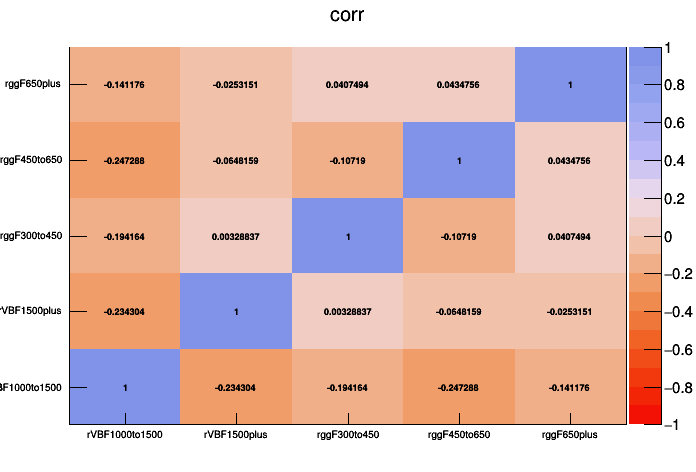

In [7]:
c = ROOT.TCanvas()
c.Draw()
corr.Draw("COLZtext")
corr.GetZaxis().SetRangeUser(-1,1)
c.Update()

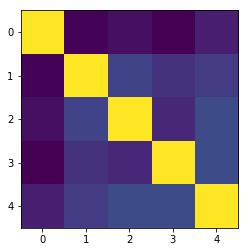

In [8]:
pycorr = np.array(corr).reshape(7,7)[1:6,1:6]
plt.imshow(pycorr)

In [9]:
print(pycorr)

[[ 1.         -0.23430443 -0.19416435 -0.24728782 -0.14117618]
 [-0.23430443  1.          0.00328837 -0.06481592 -0.0253151 ]
 [-0.19416435  0.00328837  1.         -0.10719026  0.04074941]
 [-0.24728782 -0.06481592 -0.10719026  1.          0.04347563]
 [-0.14117618 -0.0253151   0.04074941  0.04347563  1.        ]]


In [10]:
pycorr = [[ 1.,       -0.23429234, -0.1941829,  -0.24731679, -0.14115684],
          [-0.23429234, 1.,          0.00330744, -0.0648279,  -0.02531619],
          [-0.1941829,   0.00330744,  1.,         -0.10714228,  0.04075626],
          [-0.24731679, -0.0648279,  -0.10714228,  1.,          0.04348462],
          [-0.14115684, -0.02531619,  0.04075626,  0.04348462,  1.        ]]

In [11]:
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import LogNorm

import mplhep as hep
plt.style.use(hep.style.ROOT)

import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams.update({'font.size': 22})
divnorm=colors.TwoSlopeNorm(vmin=-1., vcenter=0., vmax=8.5)

/cvmfs/cms.cern.ch/slc7_amd64_gcc700/lcg/root/6.12.07-gnimlf5/lib/ROOT.py:318: DeprecationWarning: Python 2 has reached EOL. mplhep is in a deprecated mode. Please switch to Python 3.
  return _orig_ihook( name, *args, **kwds )


AttributeError: 'module' object has no attribute 'TwoSlopeNorm'

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
im = ax.imshow(pycorr,origin='lower',cmap='bwr',norm=divnorm)

ax.set_xticks(np.linspace(0,5,6))
ax.set_yticks(np.linspace(0,5,6))

ax.set_ylim(-0.5,4.5)
ax.set_xlim(-0.5,4.5)

plt.xticks(rotation=45)
#ax.set_xticklabels([k[0] for k in ggf_norm.keys()])

bins = [r'ggF $300<p_T^H<450$ GeV',r'ggF $450<p_T^H<650$ GeV',r'ggF $p_T^H>650$ GeV',r'VBF $1 < m_{jj}< 1.5$ TeV',r'VBF $m_{jj}>1.5$ TeV','extra']

ax.set_xticklabels(bins);
ax.set_yticklabels(bins);
for tick in ax.xaxis.get_majorticklabels():
    tick.set_horizontalalignment("right")

#ax.set_xlabel('ggF STXS bins')

#axcolor = fig.add_axes([0.7,0.12,0.03,0.75])
#t = [0.01, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 10, 20]
fig.colorbar(im, format="$%.1f$",label='Correlation coefficient',shrink=0.8)

for (j,i),label in np.ndenumerate(pycorr):
    ax.text(i,j,"{:.3f}".format(label),ha='center',va='center')
    
plt.savefig('correlation.png')
plt.savefig('correlation.pdf')

plt.show()